<a href="https://colab.research.google.com/github/kkeshavsharma/crypto_trading_model/blob/main/trade_V0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression and Random Forest**

## **Importing Libraries**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **Loading Dataset**

In [ ]:
df = pd.read_csv("cleandata_trade.csv")

# **Data Sepration**

In [ ]:
y = df["Closed PnL"]
x = df.drop("Closed PnL",axis=1)
x.T

,0,1,2,3,4,5,6,7,8,9,...,167847,167848,167849,167850,167851,167852,167853,167854,167855,167856
Coin,0.141991,0.141991,0.141991,0.141991,0.141991,0.141991,0.141991,0.141991,0.141991,0.141991,...,0.022015,0.022015,0.022015,0.022015,0.022015,0.022015,0.022015,0.022015,0.022015,0.022015
Execution Price,2.194655,2.195000,2.195612,2.195824,2.196046,2.196113,2.196491,2.197225,2.197225,2.197225,...,0.742413,0.742413,0.742413,0.742413,0.742413,0.742413,0.742413,0.742413,0.742413,0.742413
Size Tokens,6.895551,2.833213,4.977354,4.969674,2.275214,0.879627,4.977354,3.555348,3.850148,2.602690,...,7.514909,7.924687,7.831816,6.970918,5.433285,5.948557,7.661574,6.050676,8.188911,6.925693
Size USD,8.971215,4.857329,7.048934,7.041447,4.259153,2.507157,7.049923,5.609472,5.910797,4.615121,...,7.611076,8.020872,7.927999,7.067047,5.529112,6.044531,7.757748,6.146672,8.285105,7.021825
Side,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Start Position,0.000000,6.895201,6.911268,7.045392,7.162776,7.169516,7.170600,7.275632,7.298887,7.329511,...,9.677596,9.555482,9.337695,9.087008,8.958733,8.928985,8.877019,8.525419,8.437695,6.925693
Crossed,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fee,0.296695,0.005584,0.049201,0.048831,0.003051,0.000493,0.049201,0.011830,0.015972,0.004365,...,0.183941,0.265653,0.244738,0.110797,0.024781,0.041219,0.210150,0.045562,0.333852,0.106144
Odr_count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,...,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000,22.000000
value,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,...,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000


## **Train Test split**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 100)


# **Model Fitting**

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

#### **Making prediction**

In [ ]:
y_lr_train_pred = lr.predict(x_train)
y_lr_test_pred = lr.predict(x_test)
y_lr_train_pred

array([ 1.60495297,  2.68475504,  1.37213397, ..., -0.95598157,
        1.68678138,  0.32755097])

#### **Evaluating Model Performance**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
lr_train_mse = mean_squared_error(y_train, y_lr_train_pred)
lr_test_mse = mean_squared_error(y_test, y_lr_test_pred)
lr_train_r2= r2_score(y_train, y_lr_train_pred)
lr_test_r2= r2_score(y_test,y_lr_test_pred)

In [ ]:
lr_result = pd.DataFrame(["Linear Regression", lr_train_mse, lr_test_mse, lr_train_r2, lr_test_r2]).transpose()
lr_result.columns = ["Methord", "train mse","test mse", "train r2" , "test r2"]
lr_result

,Methord,train mse,test mse,train r2,test r2
0,Linear Regression,3.299099,3.435086,0.259515,0.25397


# **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(

    max_depth = 18,
    random_state = 100,
     )
rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=18, random_state=100)

### **model prediction**

In [ ]:
y_rf_train_pred = rf.predict(x_train)
y_rf_test_pred = rf.predict(x_test)

#### **Evaluate Model Performance**

In [ ]:
rf_train_mse = mean_squared_error(y_train,y_rf_train_pred)
rf_test_mse = mean_squared_error(y_test, y_rf_test_pred)
rf_train_r2 = r2_score(y_train, y_rf_train_pred)
rf_test_r2 = r2_score(y_test, y_rf_test_pred)

In [ ]:
rf_result = pd.DataFrame(["Random Forest",rf_train_mse, rf_test_mse, rf_train_r2, rf_test_r2]).T
rf_result.columns = ["Methord","train mse","test mse", "train r2", "test r2"]
rf_result

,Methord,train mse,test mse,train r2,test r2
0,Random Forest,0.156136,0.468733,0.964955,0.898201


# **Model Compairison**

In [ ]:
df_models= pd.concat([lr_result, rf_result], axis = 0). reset_index(drop = True)
df_models

,Methord,train mse,test mse,train r2,test r2
0,Linear Regression,3.299099,3.435086,0.259515,0.25397
1,Random Forest,0.156136,0.468733,0.964955,0.898201


# **Model Visualisation**

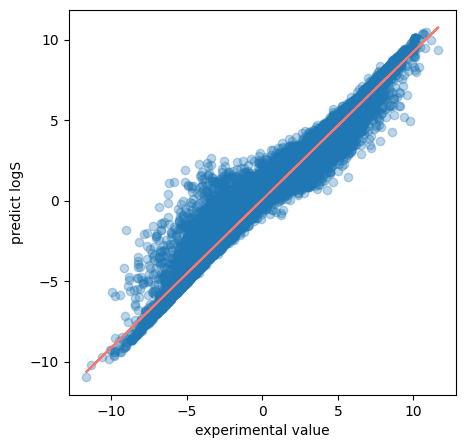

In [52]:
z=np.polyfit(y_train, y_rf_train_pred, 1)
p = np.poly1d(z)


plt.figure(figsize=(5,5))
plt.scatter(x=y_train, y=y_rf_train_pred, alpha = 0.3)
plt.plot(y_train, p(y_train), '#F8766D')
plt.ylabel('predict logS')
plt.xlabel('experimental value')
plt.show()

### **Training on diff sets**

In [ ]:
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(
#     rf,
#     x_train,
#     y_train,
#     cv=5,
#     scoring="r2"
# )

# print(scores)
# print(scores.mean())

#remove comment if needed, will take 10 minutes to execute

[0.88178699 0.88151275 0.88030295 0.87645054 0.87659611]
0.8793298690050253


In [ ]:
imp = pd.DataFrame([rf.feature_importances_, df.columns]).T.sort_values(by=0, ascending = False)
imp

,0,1
3,0.169026,Size USD
1,0.128282,Execution Price
8,0.077475,Fee
19,0.06864,Direction_Close Long
9,0.06842,Odr_count
5,0.067204,Start Position
12,0.065596,Month
18,0.06432,Direction_Buy
24,0.060917,Direction_Open Short
13,0.051709,Day


# **downloading the trained model**

In [ ]:
# import joblib

# joblib.dump(rf, "random_forest_crypto.pkl")  #236.3MB

#remove comment if needed